## Design Setup and Automatic Optimization

We automatically generate and evaluate optimal fMRI experimental designs using a genetic algorithm, and then export a detailed PDF report summarizing the results.

---

## Credit

Note: This notebook is an extension of Neurodesign's [examples](https://github.com/neuropower/neurodesign/blob/master/examples/comparison_neurodesign.ipynb).

### Step 1: Initial imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neurodesign

# Configure matplotlib for inline plotting
%matplotlib inline

In [2]:
import os
# Since Neurodesign uses multi-threading internally, limit the number of threads
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

### Step 2: Define the Experimental Setup
- **Experiment Object (`exp`)**: The experimental parameters are defined here:
  - **TR (Repetition Time)** is set to 2 seconds.
  - **n_trials**: The experiment consists of 100 trials.
  - **P**: The probabilities for each of the three conditions are set to 0.33 (equal probability).
  - **C**: The contrast matrix specifies the contrasts between conditions (e.g., condition 1 vs. condition 2).
  - **n_stimuli**: There are 3 distinct stimuli presented in the experiment.
  - **rho**: The autocorrelation between trials is set to 0.3, which models the correlation between consecutive trials.
  - **event_durations**: Each stimulus is presented for 1 second.
  - **trial_start_interval**: There is no time before the stimulus onset (trial_start_interval=0).
  - **post_event_interval**: A post-stimulus duration of 2 seconds is included.
  - **ITI Model**: The inter-trial interval (ITI) is modeled using an exponential distribution.
  - **inter_trial_interval["min"], inter_trial_interval["mean"], inter_trial_interval["max"]**: The inter-trial interval is between 1 and 4 seconds, with a mean of 2 seconds.

In [3]:
from pathlib import Path

from neurodesign import Experiment, Optimisation, report

# Define the output directory where results will be saved
output_dir = Path("./output/tuto_base-optimizing_and_reporting")
output_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------
# DEFINE EXPERIMENT PARAMETERS
# -------------------------------

# Create an Experiment object specifying the experimental setup
exp = Experiment(
    TR=2,  # Repetition time (in seconds)
    n_trials=40,  # Number of trials in the tutorial-scale run
    P=[0.33, 0.33, 0.33],  # Probabilities for three conditions (equally likely)
    C=[[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, -1, 0], [0, 1, -1]],  # Contrast matrix
    n_stimuli=3,  # Number of distinct stimuli
    rho=0.3,  # Autocorrelation between trials (correlation structure)
    resolution=0.1,  # Temporal resolution of the design
    event_durations=1,  # Duration of each stimulus presentation (in seconds)
    trial_start_interval=0,  # Time before stimulus onset
    post_event_interval=2,  # Time after stimulus offset
    inter_trial_interval={
        "model": "exponential",
        "min": 1,
        "mean": 2,
        "max": 4,
    },
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


### Step 3: Setup the Optimization Parameters
- **Optimisation Object (`population`)**: This object defines the optimization parameters:
  - **weights**: The relative importance of each metric during optimization, given in the order `[Fe, Fd, Ff, Fc]`. Here `weights=[0, 0.5, 0.25, 0.25]` means Fe (estimation) is not optimized (weight 0), Fd (detection) is weighted most heavily (0.5), and Ff (frequency balance) and Fc (confounding) are weighted equally at 0.25 each.
  - **preruncycles**: 2 warm-up cycles are run before the main optimization.
  - **cycles**: The main optimization is run for 8 cycles -- enough for the optimization trace on the report's second page to show a few real improvement steps before plateauing, rather than converging within a single generation.
  - **seed**: A random seed (100) is used for reproducibility of results.
  - **outdes**: The top 3 designs will be output after the optimization.
  - **folder**: The optimization results will be saved in the `output` folder.

In [4]:
# -------------------------------
# SETUP OPTIMIZATION PARAMETERS
# -------------------------------

# Create an Optimisation object that will be used to optimize the experimental design
population = Optimisation(
    experiment=exp,  # Link to the experiment defined above
    weights=[0, 0.5, 0.25, 0.25],  # order: Fe, Fd, Ff, Fc -> emphasize detection (Fd)
    preruncycles=2,  # Number of "warm-up" iterations before starting the optimization
    cycles=8,  # Number of optimization cycles (main iterations)
    seed=100,  # Random seed for reproducibility
    outdes=3,  # Number of output designs to return
    folder=output_dir,  # Folder where the optimization results will be saved
)

### Step 4: Run the Optimization (Natural Selection Process)
- The **optimisation** process is executed via the `optimise()` method, which runs a genetic algorithm to find the best experimental design.
- **Download**: The best designs, along with their related data, are downloaded.
- **Evaluate**: The optimized designs are evaluated based on the defined metrics (Fd, Ff, etc.).

In [5]:
# -------------------------------
# RUN NATURAL SELECTION (GENETIC ALGORITHM)
# -------------------------------

# Execute the optimization process
population.optimise()

# Download the best designs and their related data. This will output a report named "report.pdf" in the output folder.
population.download()

# Evaluate the optimization results (e.g., check efficiency metrics)
population.evaluate()

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\.venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

### Step 4b: Visualizing the Best Design

Before exporting the PDF report, it's worth looking at the selected design directly: the trial-by-trial timeline (stimulus, post-stimulus, and inter-trial intervals) and the resulting convolved design matrix and predicted BOLD signal.

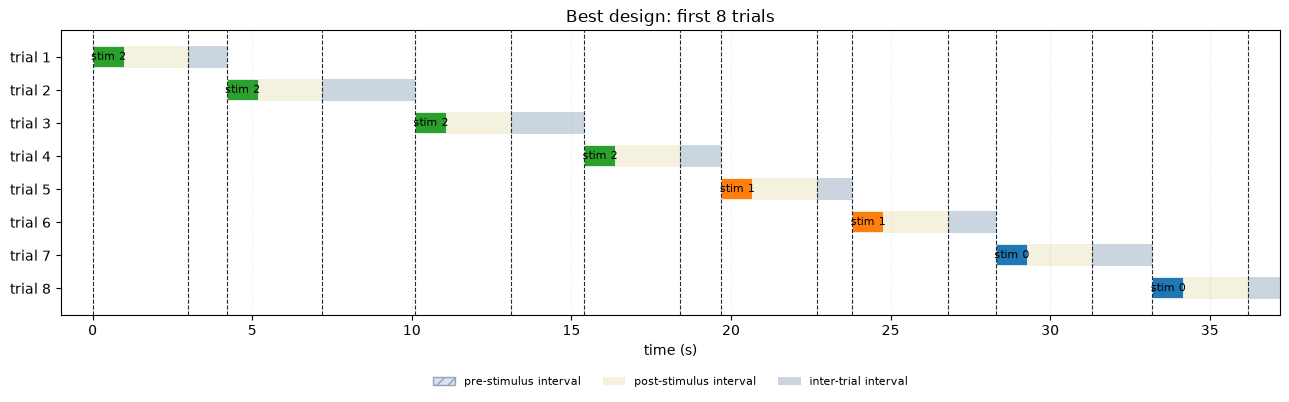

In [6]:
# -------------------------------
# VISUALIZE THE BEST DESIGN'S TRIAL TIMELINE
# -------------------------------
from matplotlib.patches import Rectangle, Patch

best_design = population.selected_design(0)


def plot_trial_timeline(design, n_trials=8):
    """Draw the first few trials as a timeline of stimulus and interval blocks."""
    rows = [row for row in design.schedule_table if row["trial_index"] < n_trials]
    labels = design.experiment.category_labels
    cmap = plt.get_cmap("tab10")
    colors = {label: cmap(i % 10) for i, label in enumerate(labels)}

    fig, ax = plt.subplots(figsize=(13, 4.2))
    for row in rows:
        y = n_trials - 1 - row["trial_index"]
        trial_start, onset, offset, trial_end = (
            row["trial_start"], row["event_onset"], row["event_offset"], row["trial_end"]
        )
        if onset > trial_start:
            ax.add_patch(Rectangle((trial_start, y - 0.34), onset - trial_start, 0.68,
                                    facecolor="#D9E2EC", edgecolor="none", hatch="///"))
        ax.add_patch(Rectangle((onset, y - 0.34), offset - onset, 0.68,
                                facecolor=colors[row["event_category"]], edgecolor="white", linewidth=1.2))
        ax.text((onset + offset) / 2, y, f"stim {row['event_category']}", ha="center", va="center",
                fontsize=8, color="black")
        post_end = offset + row["realized_post_event_interval"]
        if post_end > offset:
            ax.add_patch(Rectangle((offset, y - 0.34), post_end - offset, 0.68,
                                    facecolor="#F4F1DE", edgecolor="none"))
        inter = row["following_inter_trial_interval"] or 0.0
        if inter > 0:
            ax.add_patch(Rectangle((trial_end, y - 0.34), inter, 0.68,
                                    facecolor="#CBD5E0", edgecolor="none"))
        ax.axvline(trial_start, color="#1F2933", linewidth=0.8, linestyle="--")
        ax.axvline(trial_end, color="#1F2933", linewidth=0.8, linestyle="--")

    ax.set_yticks(range(n_trials))
    ax.set_yticklabels([f"trial {n_trials - i}" for i in range(n_trials)])
    ax.set_xlabel("time (s)")
    ax.set_title(f"Best design: first {n_trials} trials")
    ax.set_xlim(-1, max(row["trial_end"] for row in rows) + 1)
    ax.set_ylim(-0.8, n_trials - 0.2)
    ax.grid(axis="x", linestyle=":", alpha=0.3)
    ax.legend(
        handles=[
            Patch(facecolor="#D9E2EC", hatch="///", edgecolor="#94A3B8", label="pre-stimulus interval"),
            Patch(facecolor="#F4F1DE", edgecolor="none", label="post-stimulus interval"),
            Patch(facecolor="#CBD5E0", edgecolor="none", label="inter-trial interval"),
        ],
        loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=8,
    )
    fig.tight_layout()
    plt.show()


plot_trial_timeline(best_design)

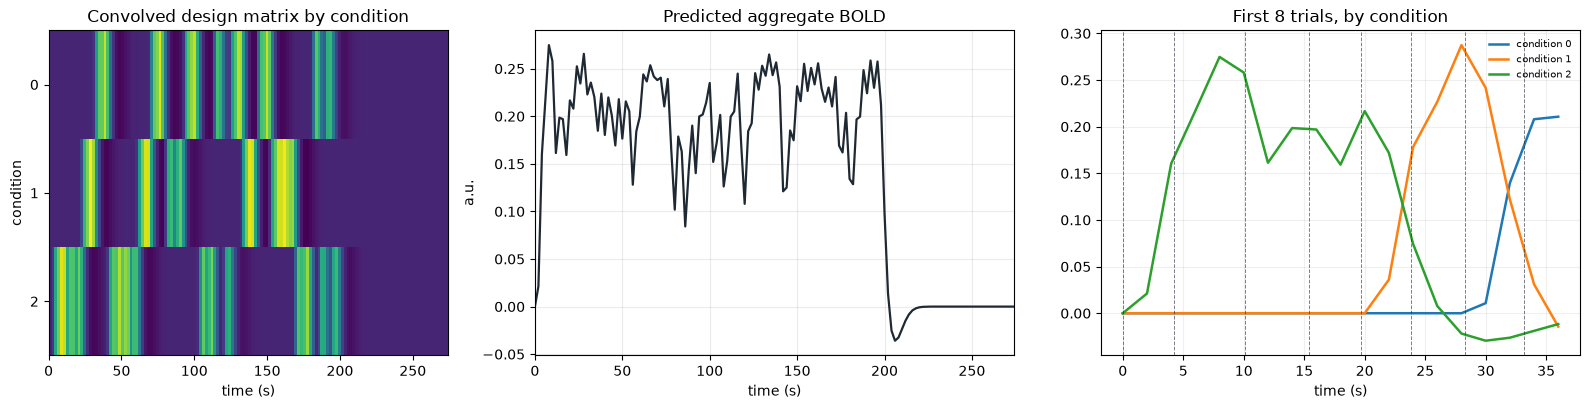

In [7]:
# -------------------------------
# VISUALIZE THE CONVOLVED DESIGN MATRIX AND PREDICTED BOLD
# -------------------------------

def plot_convolved_design(design, n_trials_zoom=8):
    """Render the convolved design matrix, aggregate BOLD, and a zoomed first-trials view."""
    xconv = np.asarray(design.Xconv)
    total_time = (xconv.shape[0] - 1) * float(design.experiment.TR)
    time = np.arange(xconv.shape[0]) * float(design.experiment.TR)
    labels = design.experiment.category_labels
    cmap = plt.get_cmap("tab10")
    colors = {label: cmap(i % 10) for i, label in enumerate(labels)}

    fig, (matrix_ax, aggregate_ax, zoom_ax) = plt.subplots(
        1, 3, figsize=(16, 4.2), gridspec_kw={"width_ratios": [1, 1.2, 1.2]}
    )

    matrix_ax.imshow(xconv.T, aspect="auto", interpolation="nearest", cmap="viridis",
                      extent=(0.0, total_time, design.experiment.n_stimuli - 0.5, -0.5))
    matrix_ax.set_title("Convolved design matrix by condition")
    matrix_ax.set_xlabel("time (s)")
    matrix_ax.set_ylabel("condition")
    matrix_ax.set_yticks(range(design.experiment.n_stimuli))
    matrix_ax.set_yticklabels(labels)

    bold = xconv.sum(axis=1)
    aggregate_ax.plot(time, bold, color="#1F2933", linewidth=1.6)
    aggregate_ax.set_title("Predicted aggregate BOLD")
    aggregate_ax.set_xlabel("time (s)")
    aggregate_ax.set_ylabel("a.u.")
    aggregate_ax.grid(alpha=0.25)
    aggregate_ax.set_xlim(0, total_time)

    zoom_idx = min(n_trials_zoom, len(design.trial_ends) - 1)
    zoom_end = design.trial_ends[zoom_idx - 1]
    mask = time <= zoom_end
    for i, label in enumerate(labels):
        zoom_ax.plot(time[mask], xconv[mask, i], color=colors[label], linewidth=1.8, label=f"condition {label}")
    for trial_idx in range(min(n_trials_zoom, len(design.trial_starts))):
        zoom_ax.axvline(design.trial_starts[trial_idx], color="#1F2933", linewidth=0.7, linestyle="--", alpha=0.6)
    zoom_ax.set_title(f"First {n_trials_zoom} trials, by condition")
    zoom_ax.set_xlabel("time (s)")
    zoom_ax.legend(fontsize=7, frameon=False)
    zoom_ax.grid(alpha=0.2)

    fig.tight_layout()
    plt.show()


plot_convolved_design(best_design)

### Step 5: Step-by-Step Simulation of Evolution
- **add_new_designs()**: New designs are added to the population after optimization.
- **to_next_generation()**: The population moves to the next generation, evolving the designs over two iterations with different random seeds.

In [8]:
# -------------------------------
# STEP BY STEP SIMULATION OF EVOLUTION
# -------------------------------

# Add new designs to the population (based on optimization process)
population.add_new_designs()

# Move to the next generation of designs using a specific random seed for reproducibility
population.to_next_generation(seed=1)
population.to_next_generation(seed=1001)

### Step 6: Export Final Report
- The final **PDF report** is generated using the `report.make_report()` function, summarizing the optimization results and the best designs found. The report is saved in the `output` folder as `test.pdf`.

In [9]:
# -------------------------------
# EXPORT FINAL REPORT
# -------------------------------

# Generate a PDF report summarizing the results of the optimization
report.make_report(population, output_dir / "tuto_optimizing_designs_report.pdf")

### Step 7: Previewing the Report Pages

`report.make_report()` writes a multi-page PDF. To preview it directly here, without opening the file separately, we rasterize each page to a PNG with `pymupdf` and walk through them below.

Page 1: Title, creation timestamp, and the design-to-design correlation matrix for the final population.


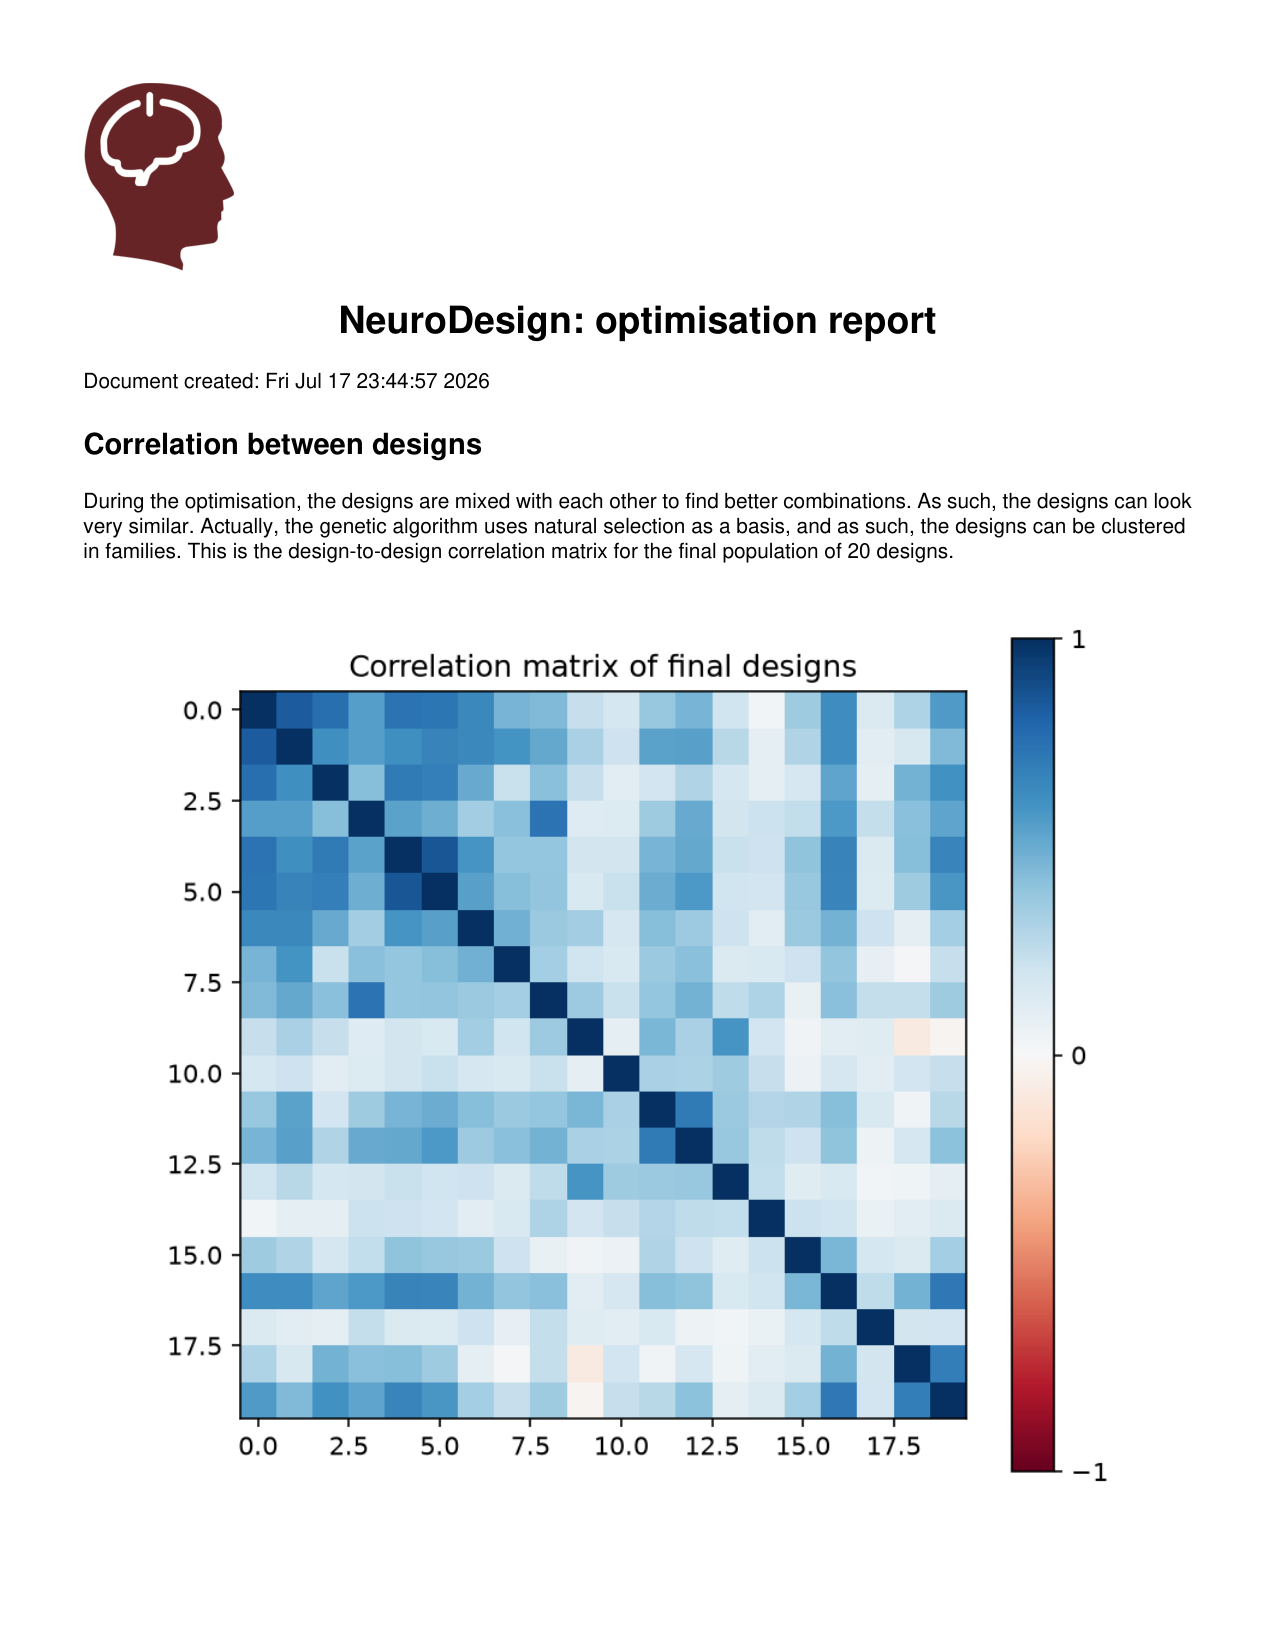

Page 2: Optimization trace (best score per generation) plus, for each selected representative design, its convolved signal, regressor correlation matrix, and singular values.


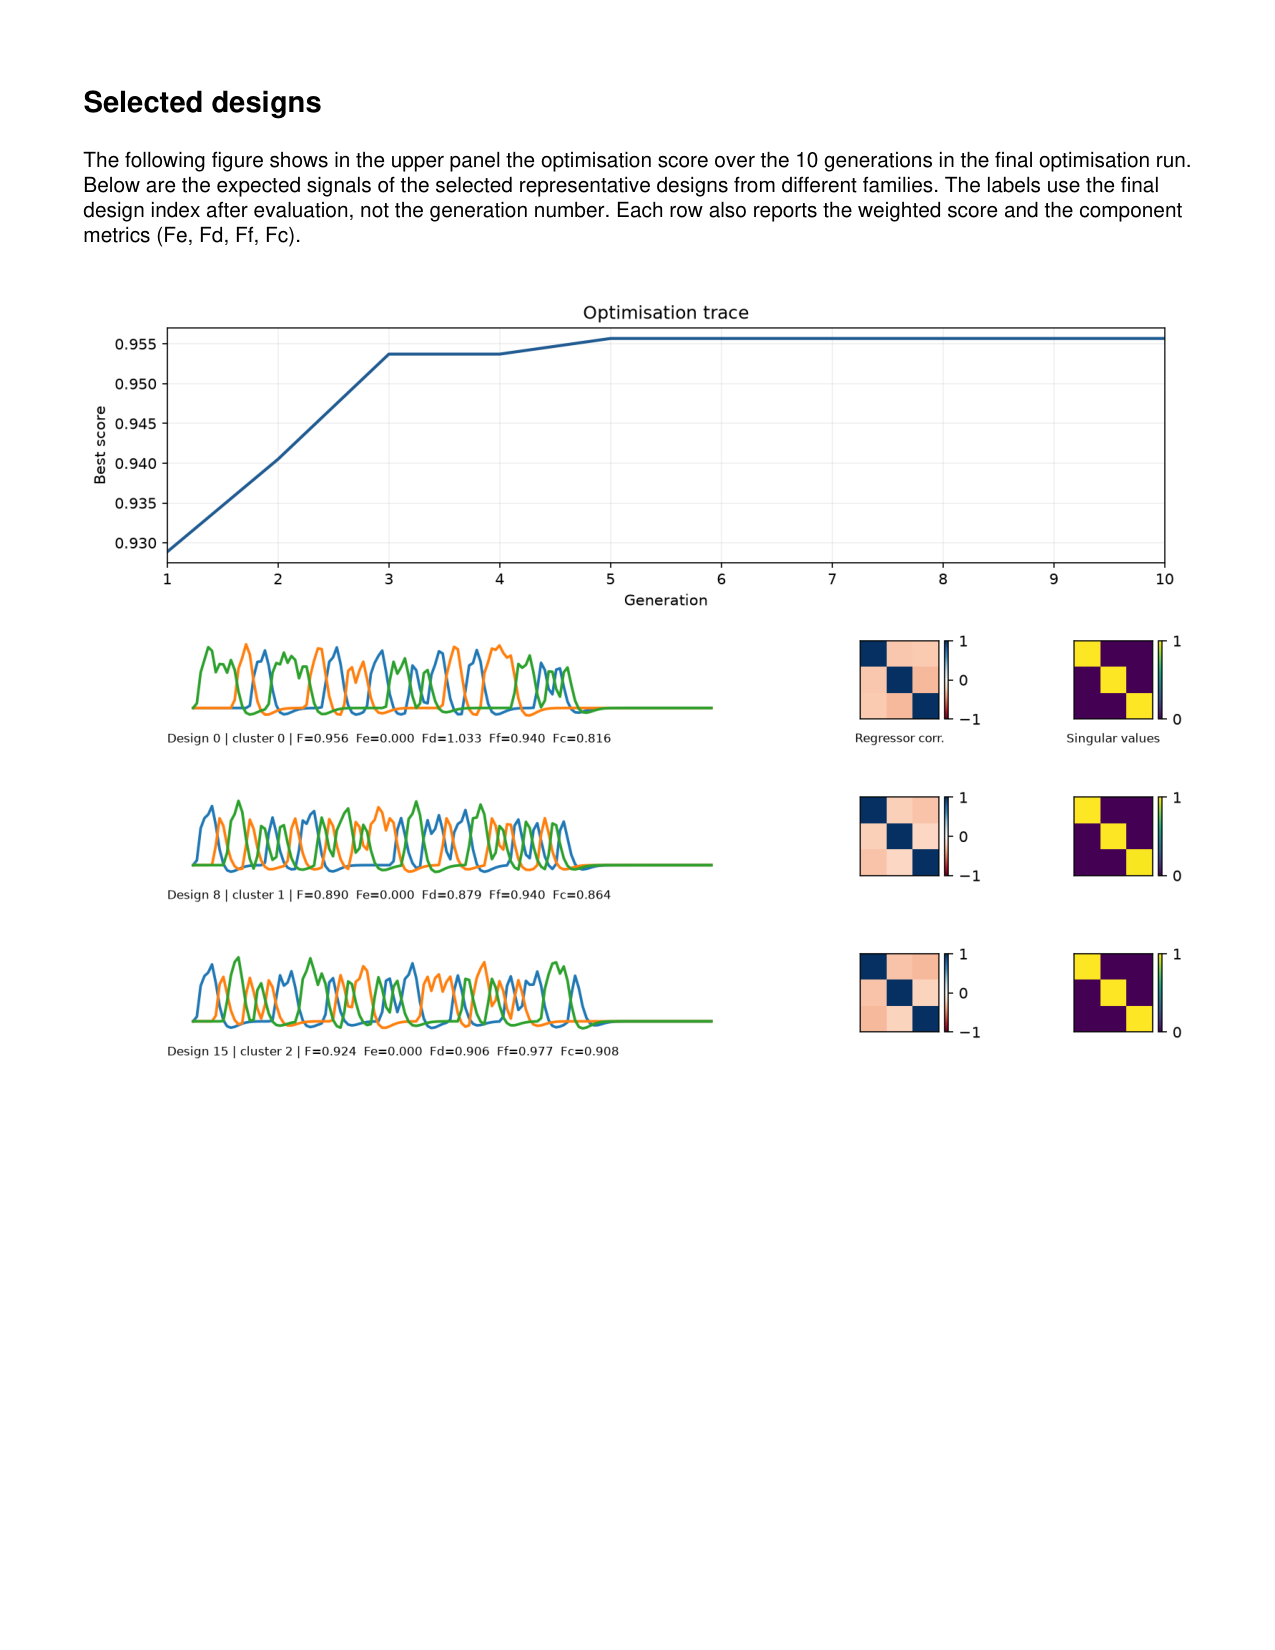

Page 3: Full experiment specification and summary table: probabilities, contrasts, weights, timing rules, and the selected design's metrics.


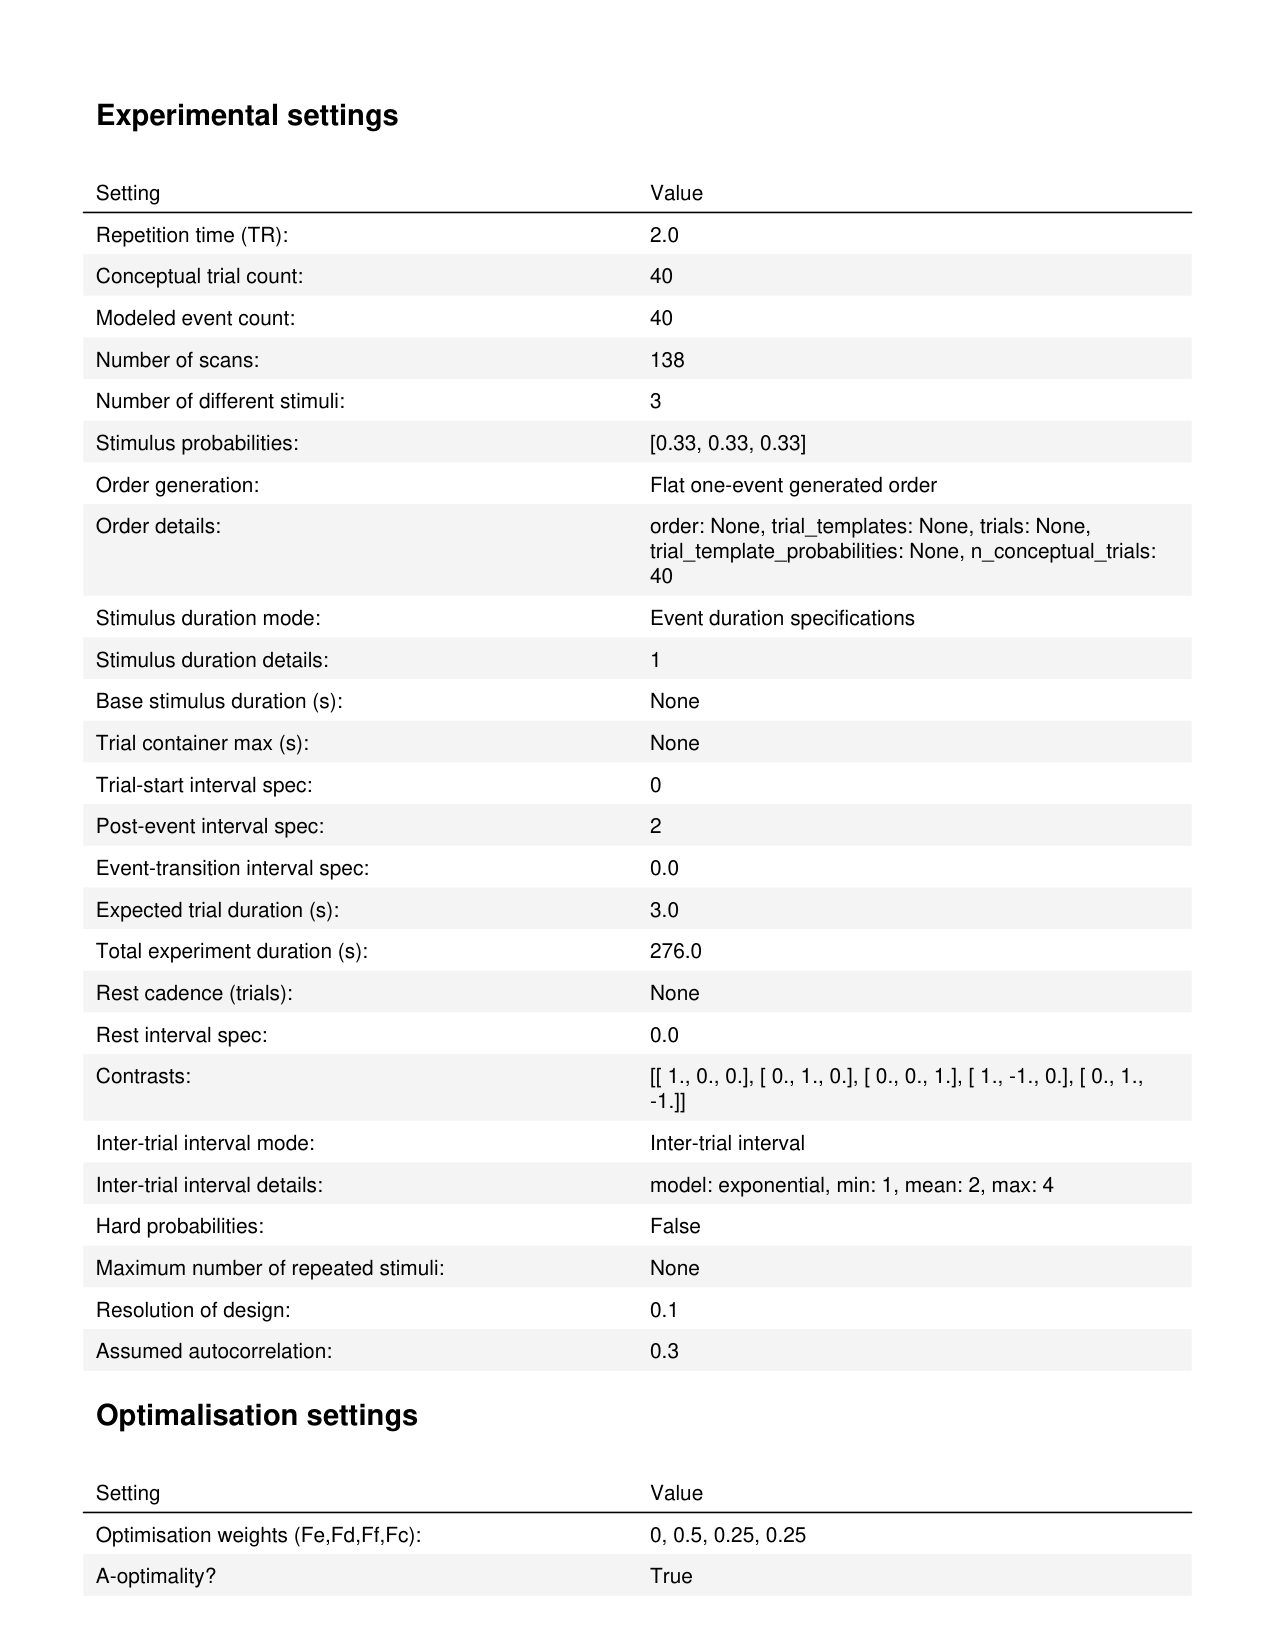

Page 4: Full experiment specification and summary table: probabilities, contrasts, weights, timing rules, and the selected design's metrics.


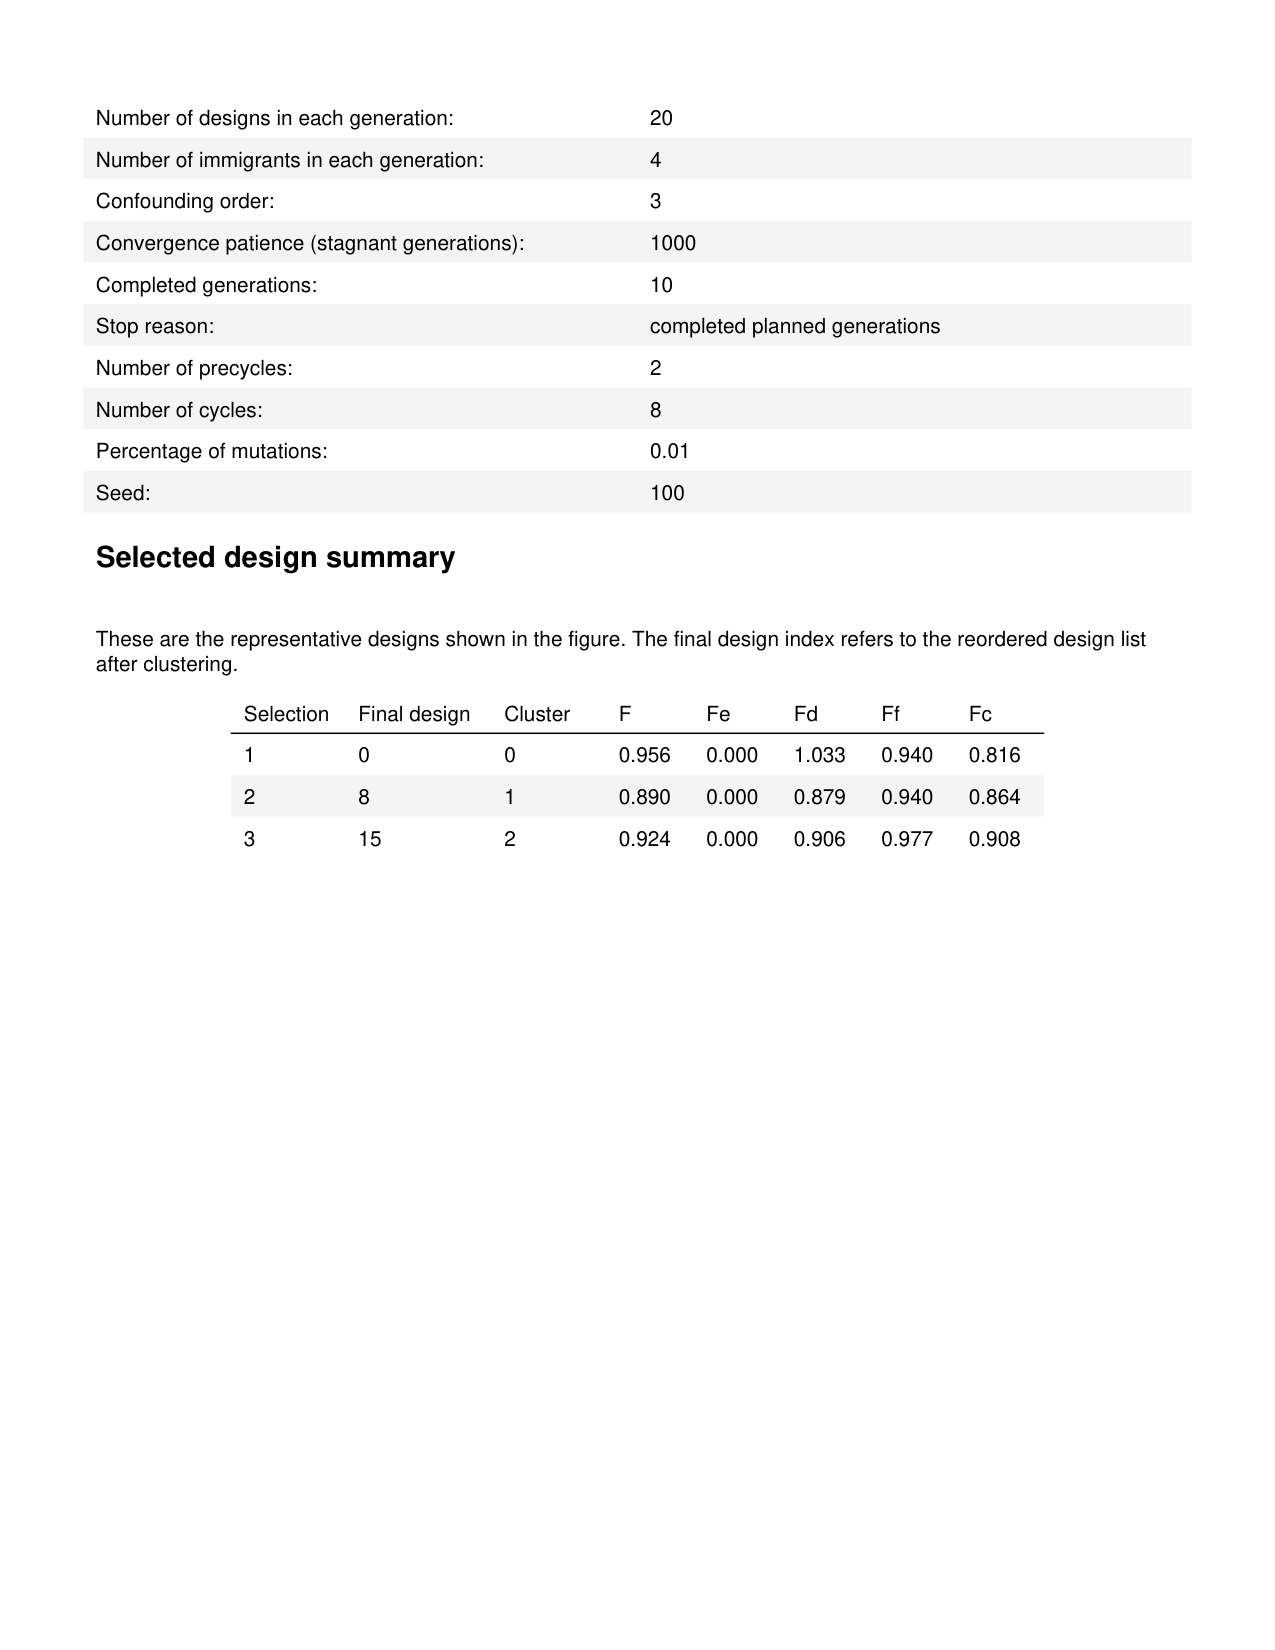

In [10]:
# -------------------------------
# RENDER AND PREVIEW THE REPORT PAGES
# -------------------------------
import fitz  # pymupdf
from IPython.display import Image, display

report_path = output_dir / "tuto_optimizing_designs_report.pdf"
report_doc = fitz.open(report_path)

page_captions = {
    0: "Title, creation timestamp, and the design-to-design correlation matrix for the final population.",
    1: "Optimization trace (best score per generation) plus, for each selected representative design, "
       "its convolved signal, regressor correlation matrix, and singular values.",
}

for page_number, page in enumerate(report_doc):
    page_png = output_dir / f"report_page-{page_number + 1}.png"
    pix = page.get_pixmap(dpi=150)
    pix.save(page_png)
    caption = page_captions.get(
        page_number,
        "Full experiment specification and summary table: probabilities, contrasts, weights, "
        "timing rules, and the selected design's metrics.",
    )
    print(f"Page {page_number + 1}: {caption}")
    display(Image(filename=str(page_png)))

report_doc.close()